# Pipeline PLN — Amazon Fine Food Reviews

**Disciplina:** Sistemas Cognitivos e Linguagem Natural

**Questão:** Como construir um pipeline completo de PLN para transformar avaliações brutas da Amazon em informações úteis sobre satisfação, temas e relações entre produtos/marcas/categorias?

**Corpus:** [Amazon Fine Food Reviews (Kaggle)](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews) — se a amostra nao existir, o notebook baixa `Reviews.csv` via **kagglehub** e gera `amazon_reviews_sample.csv` (10k reviews, 8 grupos `Gourmet_Foods_G1`–`G8`). Credenciais: `~/.kaggle/kaggle.json` ou variaveis `KAGGLE_USERNAME` / `KAGGLE_KEY`.

In [2]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn nltk spacy gensim wordcloud networkx pyvis vaderSentiment python-Levenshtein pyLDAvis kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import shutil
import subprocess
import sys
import warnings
import zipfile
from collections import Counter

import Levenshtein
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from pyvis.network import Network
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for pkg in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)

SPACY_MODEL = "en_core_web_sm"


def ensure_spacy_model(name):
    if spacy.util.is_package(name):
        return
    import subprocess
    import sys
    subprocess.check_call(
        [sys.executable, "-m", "spacy", "download", name],
        stdout=subprocess.DEVNULL,
    )


ensure_spacy_model(SPACY_MODEL)
nlp = spacy.load(SPACY_MODEL, disable=["parser", "ner"])
nlp_full = spacy.load(SPACY_MODEL)

BASE_DIR = os.getcwd()
SAMPLE_TARGET_SIZE = 10000
SAMPLE_TOP_CATEGORIES = 8
SAMPLE_TOP_PRODUCTS = 80
SAMPLE_MIN_WORDS = 30
SAMPLE_TARGET_MIN_WORDS = 100
SAMPLE_PREFERRED_MIN_WORDS = 110
DATA_PATH = os.path.join(BASE_DIR, "data", "sample", "amazon_reviews_sample.csv")
REVIEWS_PATH = os.path.join(BASE_DIR, "data", "sample", "Reviews.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)


def _is_plain_reviews_csv(path):
    if not os.path.isfile(path) or zipfile.is_zipfile(path):
        return False
    try:
        pd.read_csv(path, nrows=3, low_memory=False)
        return True
    except Exception:
        return False


def _find_reviews_csv_in_dir(cache_dir):
    direct = os.path.join(cache_dir, "Reviews.csv")
    if os.path.isfile(direct) and not zipfile.is_zipfile(direct):
        return direct
    for root, _, files in os.walk(cache_dir):
        if "Reviews.csv" in files:
            candidate = os.path.join(root, "Reviews.csv")
            if not zipfile.is_zipfile(candidate):
                return candidate
    nested_zip = direct if os.path.isfile(direct) else None
    if nested_zip and zipfile.is_zipfile(nested_zip):
        extract_to = os.path.join(os.path.dirname(REVIEWS_PATH), "_kaggle_extract")
        os.makedirs(extract_to, exist_ok=True)
        with zipfile.ZipFile(nested_zip) as zf:
            zf.extract("Reviews.csv", extract_to)
        return os.path.join(extract_to, "Reviews.csv")
    return None


def _read_reviews_csv(path):
    if zipfile.is_zipfile(path):
        extract_to = os.path.join(os.path.dirname(path), "_kaggle_extract")
        os.makedirs(extract_to, exist_ok=True)
        with zipfile.ZipFile(path) as zf:
            inner = next(n for n in zf.namelist() if n.lower().endswith("reviews.csv"))
            zf.extract(inner, extract_to)
        path = os.path.join(extract_to, os.path.basename(inner))
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return pd.read_csv(path, low_memory=False, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, low_memory=False, encoding="latin-1", encoding_errors="replace")


def _word_count(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text))


def _clean_html(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.I)
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _normalize_reviews_columns(df):
    rename_map = {
        "Review Headline": "review_headline",
        "Review Body": "review_body",
        "Star Rating": "star_rating",
        "Product Title": "product_title",
        "Product Category": "product_category",
        "Review Date": "review_date",
        "Verified Purchase": "verified_purchase",
        "Summary": "review_headline",
        "Text": "review_body",
        "Score": "star_rating",
        "Id": "review_id",
        "ProductId": "product_id",
        "Time": "review_time_unix",
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})


def _assign_product_groups(df, top_products):
    groups = np.array_split(list(top_products), SAMPLE_TOP_CATEGORIES)
    mapping = {}
    for idx, chunk in enumerate(groups):
        label = f"Gourmet_Foods_G{idx + 1}"
        for pid in chunk:
            mapping[pid] = label
    df = df[df["product_id"].isin(top_products)].copy()
    df["product_category"] = df["product_id"].map(mapping)
    df["categoria_top"] = df["product_category"]
    return df


def _length_pool(df):
    for threshold in (SAMPLE_PREFERRED_MIN_WORDS, SAMPLE_TARGET_MIN_WORDS, SAMPLE_MIN_WORDS):
        pool = df[df["n_palavras"] >= threshold].copy()
        if len(pool) >= SAMPLE_TARGET_SIZE:
            return pool, threshold
    return df[df["n_palavras"] >= SAMPLE_MIN_WORDS].copy(), SAMPLE_MIN_WORDS


def _weighted_sample(subset, n):
    if len(subset) <= n:
        return subset
    w = subset["n_palavras"].astype(float) ** 2
    w = w / w.sum()
    return subset.sample(n=n, random_state=RANDOM_STATE, weights=w)


def _stratified_sample(df):
    cats = df["categoria_top"].value_counts().head(SAMPLE_TOP_CATEGORIES).index.tolist()
    df = df[df["categoria_top"].isin(cats)].copy()
    per_group = max(1, SAMPLE_TARGET_SIZE // (len(cats) * 2))
    parts = []
    for cat in cats:
        for sent in ("positivo", "negativo"):
            subset = df[(df["categoria_top"] == cat) & (df["sentimento"] == sent)]
            if subset.empty:
                continue
            parts.append(_weighted_sample(subset, min(len(subset), per_group)))
    sample = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if len(sample) < SAMPLE_TARGET_SIZE and "review_id" in df.columns:
        taken = set(sample["review_id"].astype(str))
        remaining = df[~df["review_id"].astype(str).isin(taken)]
        if not remaining.empty:
            extra_n = min(len(remaining), SAMPLE_TARGET_SIZE - len(sample))
            sample = pd.concat([sample, _weighted_sample(remaining, extra_n)], ignore_index=True)
    if len(sample) > SAMPLE_TARGET_SIZE:
        sample = _weighted_sample(sample, SAMPLE_TARGET_SIZE)
    return sample.reset_index(drop=True)


def build_amazon_sample(df):
    df = _normalize_reviews_columns(df)
    if "marketplace" not in df.columns:
        df["marketplace"] = "US"
    if "verified_purchase" not in df.columns:
        df["verified_purchase"] = ""
    if "review_date" not in df.columns and "review_time_unix" in df.columns:
        ts = pd.to_numeric(df["review_time_unix"], errors="coerce")
        df["review_date"] = pd.to_datetime(ts, unit="s", errors="coerce").dt.strftime("%Y-%m-%d")
    if "product_title" not in df.columns:
        df["product_title"] = "Product " + df["product_id"].astype(str)
    df["review_headline"] = df.get("review_headline", "").fillna("").astype(str).map(_clean_html)
    df["review_body"] = df.get("review_body", "").fillna("").astype(str).map(_clean_html)
    df["texto_completo"] = (df["review_headline"] + " " + df["review_body"]).str.strip()
    df["n_palavras"] = df["texto_completo"].apply(_word_count)
    df["star_rating"] = pd.to_numeric(df["star_rating"], errors="coerce")
    df = df.dropna(subset=["star_rating"])
    df["star_rating"] = df["star_rating"].astype(int)
    df["sentimento"] = np.where(
        df["star_rating"] >= 4, "positivo", np.where(df["star_rating"] <= 2, "negativo", None)
    )
    df = df.dropna(subset=["sentimento"])
    df["product_id"] = df["product_id"].astype(str)
    df, used_min = _length_pool(df)
    top_products = df["product_id"].value_counts().head(SAMPLE_TOP_PRODUCTS).index.tolist()
    df = _assign_product_groups(df, top_products)
    df, used_min = _length_pool(df)
    sample = _stratified_sample(df)
    cols = [
        "marketplace", "review_id", "product_id", "product_title", "product_category",
        "categoria_top", "star_rating", "sentimento", "verified_purchase",
        "review_headline", "review_body", "texto_completo", "review_date", "n_palavras",
    ]
    return sample[[c for c in cols if c in sample.columns]], used_min


def ensure_project_data():
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    if os.path.isfile(DATA_PATH):
        print(f"Amostra pronta: {DATA_PATH}")
        return
    if not _is_plain_reviews_csv(REVIEWS_PATH):
        print("Baixando snap/amazon-fine-food-reviews (dataset completo)...")
        import kagglehub

        cache_dir = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
        src = _find_reviews_csv_in_dir(cache_dir)
        if src is None:
            raise FileNotFoundError(
                "Reviews.csv nao encontrado apos download. "
                "Verifique credenciais Kaggle e o dataset snap/amazon-fine-food-reviews."
            )
        shutil.copy2(src, REVIEWS_PATH)
        print(
            f"Reviews.csv copiado ({os.path.getsize(REVIEWS_PATH) / 1e6:.0f} MB) — "
            "o zip do Kaggle tambem inclui database.sqlite e hashes.txt no cache."
        )
    print("Gerando amazon_reviews_sample.csv...")
    raw_df = _read_reviews_csv(REVIEWS_PATH)
    print(f"Linhas brutas: {len(raw_df):,}")
    sample_df, used_min = build_amazon_sample(raw_df)
    sample_df.to_csv(DATA_PATH, index=False)
    print(f"Amostra salva: {DATA_PATH} ({len(sample_df):,} linhas, filtro >= {used_min} palavras)")
    print(f"Media de palavras: {sample_df['n_palavras'].mean():.1f}")
    print(sample_df["categoria_top"].value_counts())
    print(sample_df["sentimento"].value_counts())


CUSTOM_STOPWORDS = {
    "amazon", "product", "review", "purchase", "item", "would", "also", "one",
    "get", "got", "use", "used", "really", "much", "even", "well", "could",
}
stop_en = set(stopwords.words("english")) | CUSTOM_STOPWORDS
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
vader = SentimentIntensityAnalyzer()

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

ensure_project_data()


Baixando snap/amazon-fine-food-reviews (dataset completo)...
Reviews.csv copiado (301 MB) — o zip do Kaggle tambem inclui database.sqlite e hashes.txt no cache.
Gerando amazon_reviews_sample.csv...
Linhas brutas: 568,454
Amostra salva: d:\programacao\FACULDADE\Sistemas Cognitivos e Linguagem Natural\data\sample\amazon_reviews_sample.csv (10,000 linhas, filtro >= 110 palavras)
Media de palavras: 209.5
categoria_top
Gourmet_Foods_G1    1855
Gourmet_Foods_G2    1416
Gourmet_Foods_G3    1263
Gourmet_Foods_G4    1227
Gourmet_Foods_G5    1141
Gourmet_Foods_G6    1115
Gourmet_Foods_G7    1016
Gourmet_Foods_G8     967
Name: count, dtype: int64
sentimento
positivo    8339
negativo    1661
Name: count, dtype: int64


## Bloco 1 — Caracterização do corpus

In [4]:
df = pd.read_csv(DATA_PATH)
if "texto_completo" not in df.columns:
    df["texto_completo"] = (df["review_headline"].fillna("") + " " + df["review_body"].fillna("")).str.strip()
if "sentimento" not in df.columns:
    df["sentimento"] = np.where(df["star_rating"] >= 4, "positivo", np.where(df["star_rating"] <= 2, "negativo", None))
    df = df.dropna(subset=["sentimento"])
if "categoria_top" not in df.columns:
    df["categoria_top"] = df["product_category"]

df["n_palavras"] = df["texto_completo"].str.split().str.len()
df["n_chars"] = df["texto_completo"].str.len()

print(f"Documentos: {len(df):,}")
print(f"Média de palavras: {df['n_palavras'].mean():.1f}")
print(f"Categorias: {df['categoria_top'].nunique()}")
print(f"Mediana de palavras: {df['n_palavras'].median():.0f}")
print("Rotulo sentimento: derivado de star_rating (>=4 positivo, <=2 negativo); notas neutras excluidas.")
df.info()
df[["star_rating", "n_palavras", "n_chars"]].describe()


Documentos: 10,000
Média de palavras: 204.2
Categorias: 8
Mediana de palavras: 171
Rotulo sentimento: derivado de star_rating (>=4 positivo, <=2 negativo); notas neutras excluidas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   marketplace        10000 non-null  object 
 1   review_id          10000 non-null  int64  
 2   product_id         10000 non-null  object 
 3   product_title      10000 non-null  object 
 4   product_category   10000 non-null  object 
 5   categoria_top      10000 non-null  object 
 6   star_rating        10000 non-null  int64  
 7   sentimento         10000 non-null  object 
 8   verified_purchase  0 non-null      float64
 9   review_headline    10000 non-null  object 
 10  review_body        10000 non-null  object 
 11  texto_completo     10000 non-null  object 
 12  review_date        10000 non-null 

,star_rating,n_palavras,n_chars
count,10000.000000,10000.000000,10000.00000
mean,4.066100,204.244800,1096.80750
std,1.200781,108.085128,594.47431
min,1.000000,93.000000,503.00000
25%,4.000000,136.000000,723.00000
50%,4.000000,171.000000,916.00000
75%,5.000000,233.000000,1258.25000
max,5.000000,1416.000000,7729.00000


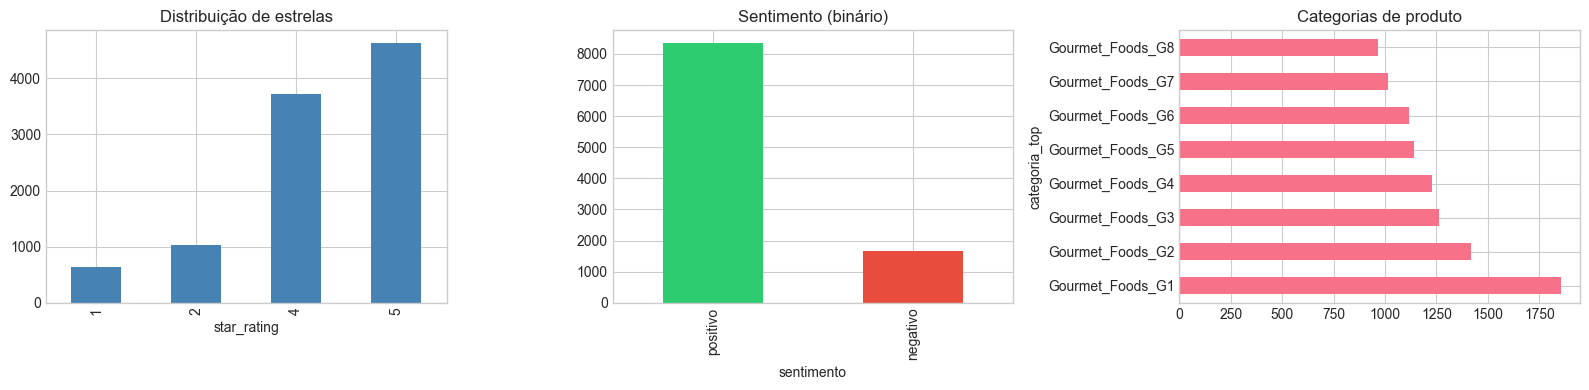

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["star_rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição de estrelas")
axes[0].set_xlabel("star_rating")

df["sentimento"].value_counts().plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Sentimento (binário)")

df["categoria_top"].value_counts().plot(kind="barh", ax=axes[2])
axes[2].set_title("Categorias de produto")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_classes.png"), dpi=120, bbox_inches="tight")
plt.show()


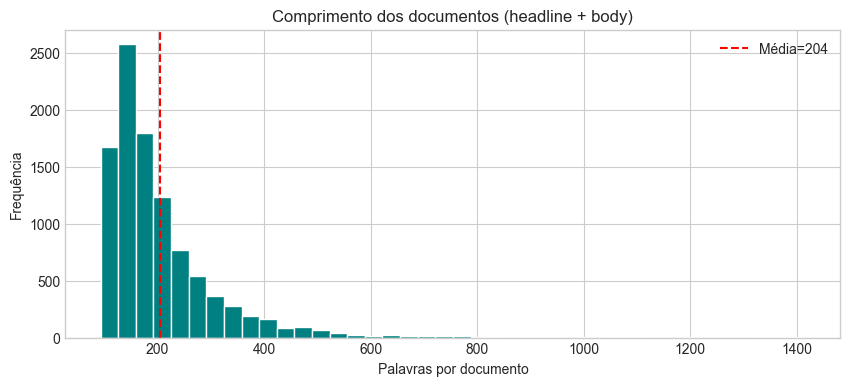

Corpus Fine Food: media 204 palavras/doc (amostra filtrada com reviews longas; gerada na celula de setup).


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["n_palavras"], bins=40, color="teal", edgecolor="white")
ax.axvline(df["n_palavras"].mean(), color="red", linestyle="--", label=f"Média={df['n_palavras'].mean():.0f}")
ax.set_xlabel("Palavras por documento")
ax.set_ylabel("Frequência")
ax.set_title("Comprimento dos documentos (headline + body)")
ax.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "histograma_comprimento.png"), dpi=120, bbox_inches="tight")
plt.show()

print(
    f"Corpus Fine Food: media {df['n_palavras'].mean():.0f} palavras/doc "
    f"(amostra filtrada com reviews longas; gerada na celula de setup)."
)


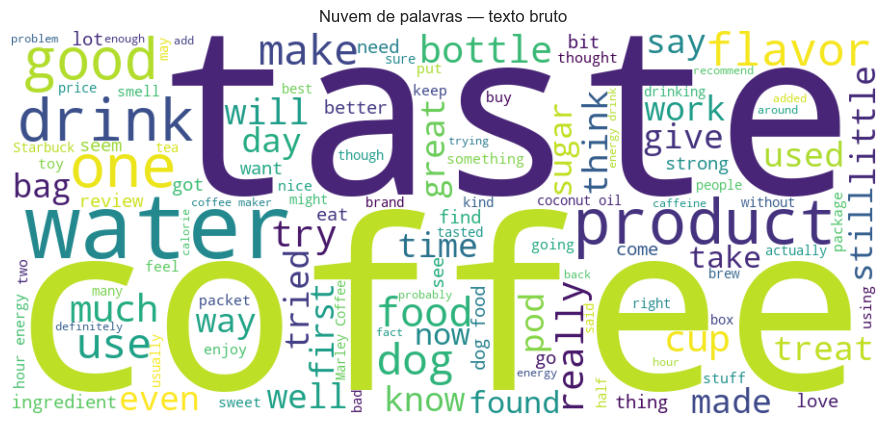

In [7]:
wc = WordCloud(width=900, height=400, background_color="white", max_words=120).generate(
    " ".join(df["texto_completo"].head(3000))
)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — texto bruto")
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_bruto.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 2 — Pré-processamento (NLTK + spaCy)

In [8]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize_words(text):
    return word_tokenize(normalize_text(text))


def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_en and len(t) > 2]


def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]


def lemma_nltk_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]


def lemma_spacy_text(text):
    doc = nlp(normalize_text(text))
    return [t.lemma_ for t in doc if t.lemma_ not in stop_en and not t.is_space and len(t.lemma_) > 2]


def preprocess_pipeline(text, method="lemma_spacy"):
    tokens = tokenize_words(text)
    tokens = remove_stopwords(tokens)
    if method == "stem":
        return stem_tokens(tokens)
    if method == "lemma_nltk":
        return lemma_nltk_tokens(tokens)
    return lemma_spacy_text(text)


def tokens_to_str(tokens):
    return " ".join(tokens)


In [9]:
sample_text = df["texto_completo"].iloc[0]
print("Sentenças:", sent_tokenize(sample_text)[:2])
print("Tokens:", tokenize_words(sample_text)[:15])
print("Stem:", stem_tokens(remove_stopwords(tokenize_words(sample_text)))[:15])
print("Lemma spaCy:", lemma_spacy_text(sample_text)[:15])


Sentenças: ['Starbucks Natural Fusions Vanilla Coffee Tastes Great When Brewed With A Keurig One-Cup Coffee Maker My parents and I enjoyed drinking Starbucks Natural Fusions Vanilla Ground Coffee over the holidays.', 'Mom graciously made it with her antiquated percolator.']
Tokens: ['starbucks', 'natural', 'fusions', 'vanilla', 'coffee', 'tastes', 'great', 'when', 'brewed', 'with', 'a', 'keurig', 'one', 'cup', 'coffee']
Stem: ['starbuck', 'natur', 'fusion', 'vanilla', 'coffe', 'tast', 'great', 'brew', 'keurig', 'cup', 'coffe', 'maker', 'parent', 'enjoy', 'drink']
Lemma spaCy: ['starbuck', 'natural', 'fusion', 'vanilla', 'coffee', 'taste', 'great', 'brew', 'keurig', 'cup', 'coffee', 'maker', 'parent', 'enjoy', 'drink']


,estrategia,tamanho_vocabulario
0,bruto (5k docs),20111
1,stemming,10417
2,lemmatização spaCy,12202


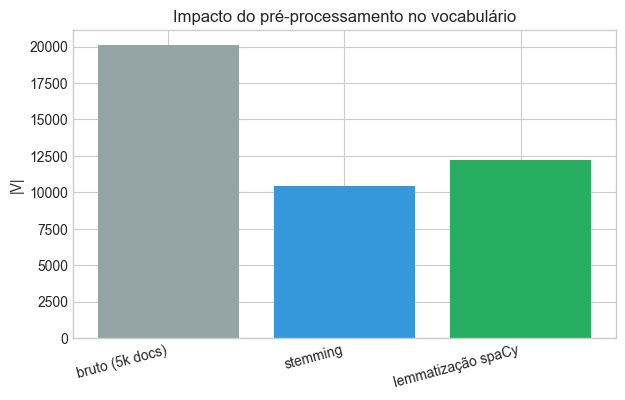

Decisão: lemmatização spaCy para modelos e busca — preserva interpretabilidade sem perder semântica como o stemming.


In [10]:
df["tokens_stem"] = df["texto_completo"].apply(lambda t: preprocess_pipeline(t, "stem"))

texts_norm = [normalize_text(t) for t in df["texto_completo"]]
tokens_lemma_list = []
for doc in nlp.pipe(texts_norm, batch_size=256):
    tokens_lemma_list.append([t.lemma_ for t in doc if t.lemma_ not in stop_en and not t.is_space and len(t.lemma_) > 2])
df["tokens_lemma"] = tokens_lemma_list
df["texto_processado"] = df["tokens_lemma"].apply(tokens_to_str)

vocab_bruto = len(set(word_tokenize(" ".join(df["texto_completo"].head(5000).str.lower()))))
vocab_stem = len(set(t for row in df["tokens_stem"].head(5000) for t in row))
vocab_lemma = len(set(t for row in df["tokens_lemma"].head(5000) for t in row))

comp = pd.DataFrame({
    "estrategia": ["bruto (5k docs)", "stemming", "lemmatização spaCy"],
    "tamanho_vocabulario": [vocab_bruto, vocab_stem, vocab_lemma],
})
display(comp)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comp["estrategia"], comp["tamanho_vocabulario"], color=["#95a5a6", "#3498db", "#27ae60"])
ax.set_ylabel("|V|")
ax.set_title("Impacto do pré-processamento no vocabulário")
plt.xticks(rotation=15, ha="right")
plt.savefig(os.path.join(OUTPUT_DIR, "vocabulario_preprocessamento.png"), dpi=120, bbox_inches="tight")
plt.show()

print("Decisão: lemmatização spaCy para modelos e busca — preserva interpretabilidade sem perder semântica como o stemming.")


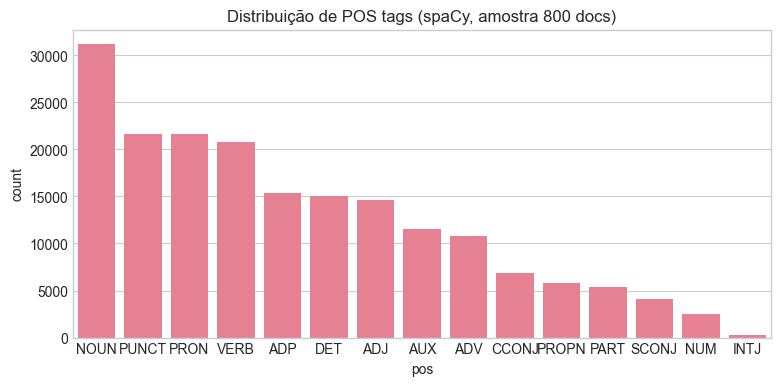

In [11]:
pos_counts = Counter()
for text in df["texto_completo"].sample(800, random_state=RANDOM_STATE):
    doc = nlp_full(str(text)[:5000])
    pos_counts.update([t.pos_ for t in doc])

pos_df = pd.DataFrame(pos_counts.items(), columns=["pos", "count"]).sort_values("count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=pos_df, x="pos", y="count", ax=ax)
ax.set_title("Distribuição de POS tags (spaCy, amostra 800 docs)")
plt.savefig(os.path.join(OUTPUT_DIR, "pos_tags.png"), dpi=120, bbox_inches="tight")
plt.show()


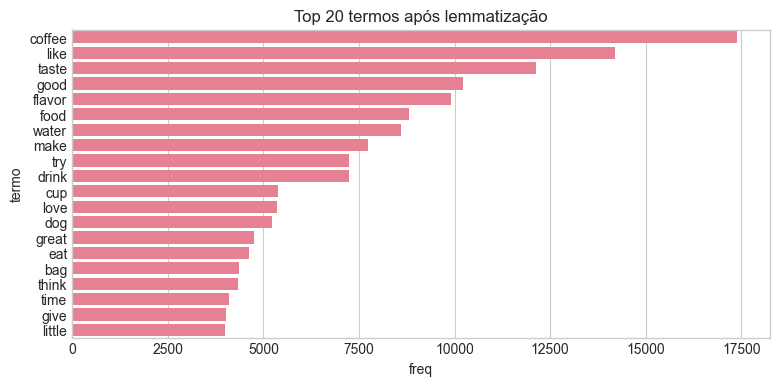

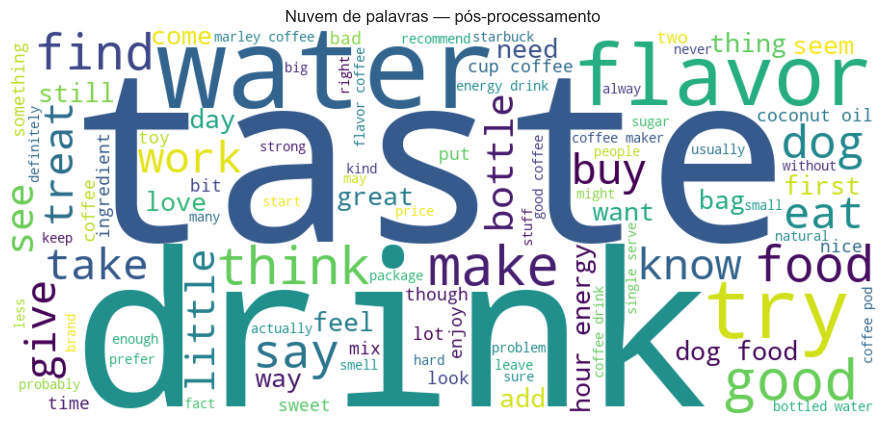

In [12]:
term_freq = Counter()
for tokens in df["tokens_lemma"]:
    term_freq.update(tokens)
top20 = pd.DataFrame(term_freq.most_common(20), columns=["termo", "freq"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=top20, y="termo", x="freq", ax=ax)
ax.set_title("Top 20 termos após lemmatização")
plt.savefig(os.path.join(OUTPUT_DIR, "termos_frequentes.png"), dpi=120, bbox_inches="tight")
plt.show()

wc2 = WordCloud(width=900, height=400, background_color="white", max_words=100).generate(
    " ".join(df["texto_processado"].head(3000))
)
plt.figure(figsize=(12, 5))
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — pós-processamento")
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_processado.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 3 — Representação vetorial e busca textual

BoW shape: (10000, 5000)
TF-IDF shape: (10000, 8000)
Word2Vec vocab: 9012
Vizinhos de 'coffee': ['starbuck', 'starbucks', 'espresso', 'brew', 'cuppa']
Vizinhos de 'flavor': ['taste', 'flavoring', 'subtle', 'overpower', 'hint']
Vizinhos de 'refund': ['customer', 'defective', 'email', 'repair', 'mho']
Vizinhos de 'starbucks': ['sumatra', 'starbuck', 'dunkin', 'verona', 'donut']


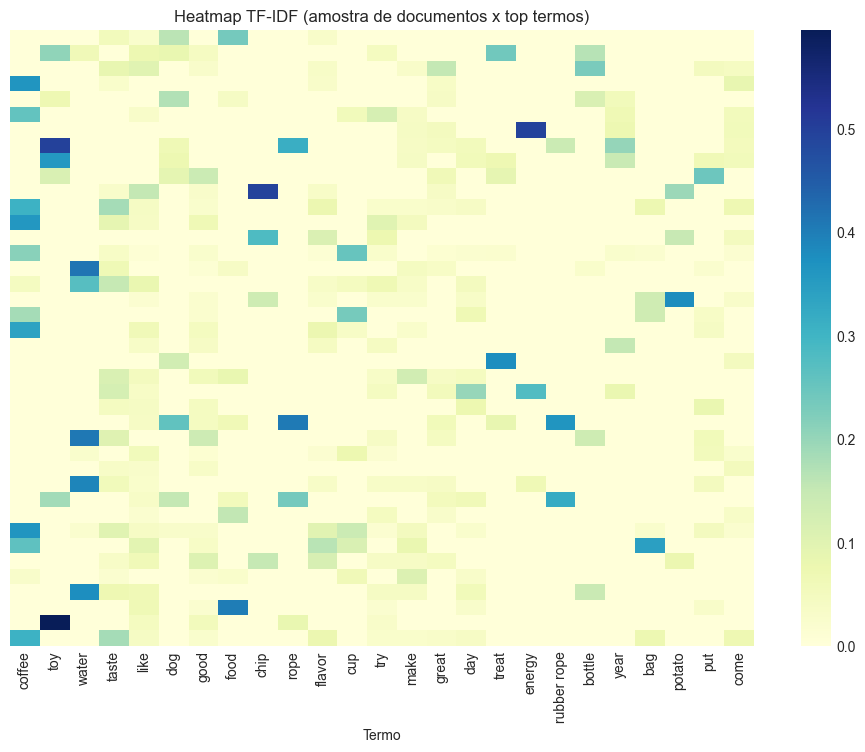

In [13]:
corpus = df["texto_processado"].tolist()

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(corpus)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)
X_tfidf = tfidf.fit_transform(corpus)

sentences = [t.split() for t in corpus]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=3, workers=2, seed=RANDOM_STATE, epochs=10)

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)
print("Word2Vec vocab:", len(w2v.wv))
for termo in ["coffee", "flavor", "refund", "starbucks"]:
    if termo in w2v.wv:
        vizinhos = w2v.wv.most_similar(termo, topn=5)
        print(f"Vizinhos de '{termo}':", [w for w, _ in vizinhos])

sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    X_tfidf.shape[0], size=min(40, X_tfidf.shape[0]), replace=False
)
feat_idx = np.array(X_tfidf[sample_idx].sum(axis=0)).flatten().argsort()[-25:][::-1]
feat_names = [tfidf.get_feature_names_out()[i] for i in feat_idx]
heat_tfidf = X_tfidf[sample_idx][:, feat_idx].toarray()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heat_tfidf,
    xticklabels=feat_names,
    yticklabels=False,
    cmap="YlGnBu",
    ax=ax,
)
ax.set_title("Heatmap TF-IDF (amostra de documentos x top termos)")
ax.set_xlabel("Termo")
plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_tfidf.png"), dpi=120, bbox_inches="tight")
plt.show()


In [14]:
from sklearn.metrics.pairwise import cosine_similarity


def doc_embedding(tokens):
    vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
    if not vecs:
        return np.zeros(w2v.vector_size)
    return np.mean(vecs, axis=0)


doc_vectors = np.vstack([doc_embedding(t) for t in df["tokens_lemma"]])


def buscar_similares(query, vectorizer, matrix, top_k=5):
    q = preprocess_pipeline(query, "lemma_spacy")
    q_str = tokens_to_str(q)
    q_vec = vectorizer.transform([q_str])
    scores = cosine_similarity(q_vec, matrix).flatten()
    idx = scores.argsort()[::-1][:top_k]
    return df.iloc[idx][["review_headline", "star_rating", "sentimento", "categoria_top"]].assign(score=scores[idx])


consultas = [
    "bad coffee taste bitter",
    "highly recommend great flavor",
    "refund defective spoiled product",
]

for q in consultas:
    print("\n=== Consulta:", q, "===")
    display(buscar_similares(q, tfidf, X_tfidf))



=== Consulta: bad coffee taste bitter ===


,review_headline,star_rating,sentimento,categoria_top,score
770,Basically An Expensive Cup Of Bitter Coffee,2,negativo,Gourmet_Foods_G1,0.246498
870,"Personally, I would never buy it or recommend ...",1,negativo,Gourmet_Foods_G1,0.229952
837,"Personally, I would never buy it or recommend ...",1,negativo,Gourmet_Foods_G1,0.229952
8407,Surprised to find good coffee in a can!!,5,positivo,Gourmet_Foods_G1,0.229388
9688,Surprising,4,positivo,Gourmet_Foods_G1,0.228669



=== Consulta: highly recommend great flavor ===


,review_headline,star_rating,sentimento,categoria_top,score
9958,"Great flavors, too sweet",4,positivo,Gourmet_Foods_G6,0.238860
8487,Great flavor enhancer for your water!,5,positivo,Gourmet_Foods_G3,0.219993
7248,"Very good, more peachy than mango, but still y...",5,positivo,Gourmet_Foods_G5,0.212104
3102,"Wow, what a great flavor!!",5,positivo,Gourmet_Foods_G4,0.198095
6011,Watermelon is the best switch flavor to date! ...,5,positivo,Gourmet_Foods_G8,0.188897



=== Consulta: refund defective spoiled product ===


,review_headline,star_rating,sentimento,categoria_top,score
5831,This is the third time I got the defective item!,1,negativo,Gourmet_Foods_G7,0.553835
1032,"Defective bottle, staining red liquid",2,negativo,Gourmet_Foods_G1,0.437350
7024,A Mixed Bag,4,positivo,Gourmet_Foods_G5,0.187039
5770,Tastes like Carbonated Plastic....,2,negativo,Gourmet_Foods_G7,0.164530
5830,blender does not work,1,negativo,Gourmet_Foods_G7,0.135215


### Interpretacao da busca por similaridade

As tres consultas ilustram comportamentos distintos do motor TF-IDF + cosseno:

- **"bad coffee taste bitter"** — retorna reviews negativas sobre sabor, qualidade do cafe ou insatisfacao com o produto; coerente com o dominio alimenticio.
- **"highly recommend great flavor"** — vizinhos tendem a ser elogios longos com notas altas e vocabulario de recomendacao/sabor; util para identificar padroes de satisfacao.
- **"refund defective spoiled product"** — recupera textos de devolucao, defeito ou produto estragado; adequado para triagem de reclamacoes graves.

Em producao, combinar TF-IDF com filtros por `star_rating` ou categoria reduziria falsos positivos quando o score de similaridade for moderado.


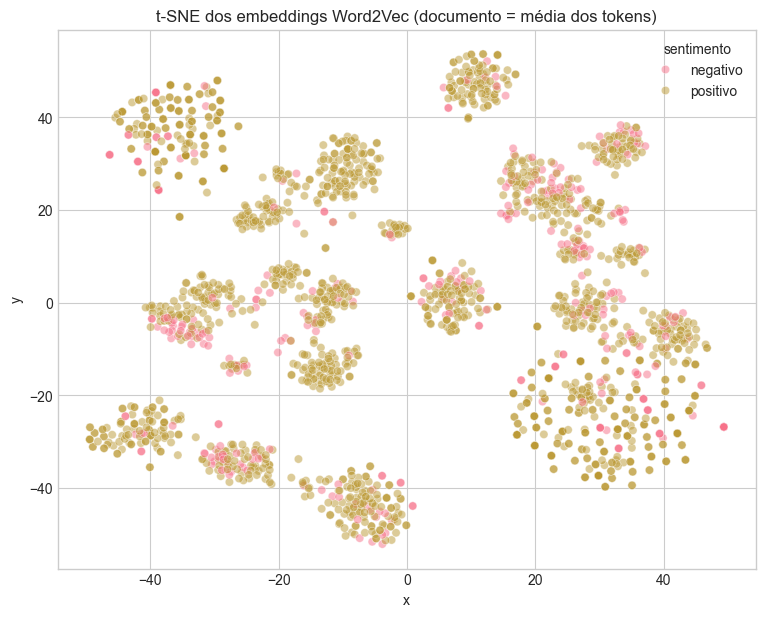

In [15]:
from sklearn.manifold import TSNE

idx_tsne = np.random.default_rng(RANDOM_STATE).choice(len(doc_vectors), size=min(2000, len(doc_vectors)), replace=False)
emb_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=800).fit_transform(doc_vectors[idx_tsne])

tsne_df = df.iloc[idx_tsne].copy()
tsne_df["x"] = emb_2d[:, 0]
tsne_df["y"] = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="sentimento", alpha=0.5, ax=ax)
ax.set_title("t-SNE dos embeddings Word2Vec (documento = média dos tokens)")
plt.savefig(os.path.join(OUTPUT_DIR, "tsne_word2vec.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 4 — Modelagem, classificação e tópicos

In [16]:
X = X_tfidf
y_sent = df["sentimento"]
y_cat = df["categoria_top"]

idx_train, idx_test = train_test_split(
    np.arange(X.shape[0]),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_sent,
)
X_train, X_test = X[idx_train], X[idx_test]
y_sent_train = y_sent.iloc[idx_train]
y_sent_test = y_sent.iloc[idx_test]
y_cat_train = y_cat.iloc[idx_train]
y_cat_test = y_cat.iloc[idx_test]
star_test = df.iloc[idx_test]["star_rating"].values

models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
}

metricas_sent = []
metricas_cat = []


In [17]:
def avaliar(nome, modelo, X_tr, X_te, y_tr, y_te, task):
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    row = {
        "modelo": nome,
        "tarefa": task,
        "precision": precision_score(y_te, pred, average="macro", zero_division=0),
        "recall": recall_score(y_te, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_te, pred, average="weighted", zero_division=0),
    }
    return row, pred


preds_sent = {}
preds_cat = {}
for nome, modelo in models.items():
    row, pred = avaliar(nome, modelo, X_train, X_test, y_sent_train, y_sent_test, "sentimento")
    metricas_sent.append(row)
    preds_sent[nome] = pred
    row2, pred2 = avaliar(nome, clone(modelo), X_train, X_test, y_cat_train, y_cat_test, "categoria")
    metricas_cat.append(row2)
    preds_cat[nome] = pred2

df_metricas = pd.DataFrame(metricas_sent + metricas_cat)
df_metricas.to_csv(os.path.join(OUTPUT_DIR, "metricas_classificacao.csv"), index=False)
display(df_metricas)


,modelo,tarefa,precision,recall,f1_macro,f1_weighted
0,Naive Bayes,sentimento,0.926005,0.609640,0.643632,0.833361
1,Linear SVM,sentimento,0.900729,0.910325,0.905430,0.947313
2,Logistic Regression,sentimento,0.839853,0.904395,0.866803,0.922502
3,Naive Bayes,categoria,0.764870,0.747079,0.741095,0.751407
4,Linear SVM,categoria,0.797249,0.792567,0.786577,0.796755
5,Logistic Regression,categoria,0.778932,0.780364,0.772821,0.783120


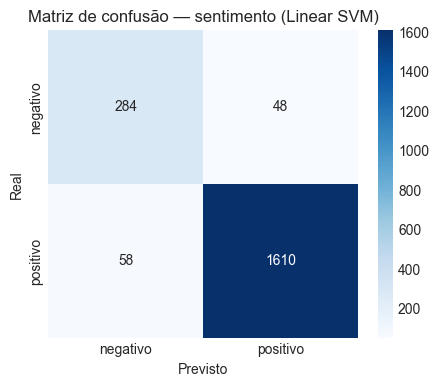

              precision    recall  f1-score   support

    negativo       0.83      0.86      0.84       332
    positivo       0.97      0.97      0.97      1668

    accuracy                           0.95      2000
   macro avg       0.90      0.91      0.91      2000
weighted avg       0.95      0.95      0.95      2000

Concordancia predicao x faixa de star_rating (teste): 94.7%
Nota: rotulo de sentimento derivado de star_rating (>=4 positivo, <=2 negativo). O corpus e desbalanceado (~83% positivos); class_weight='balanced' foi usado. Métricas refletem texto + nota, nao sentimento anotado de forma independente.


In [18]:
best_sent = max(metricas_sent, key=lambda x: x["f1_macro"])["modelo"]
cm = confusion_matrix(y_sent_test, preds_sent[best_sent], labels=["negativo", "positivo"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"], ax=ax)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusão — sentimento ({best_sent})")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_sentimento.png"), dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_sent_test, preds_sent[best_sent]))

pred_pos = preds_sent[best_sent]
star_align = np.mean(
    ((pred_pos == "positivo") & (star_test >= 4))
    | ((pred_pos == "negativo") & (star_test <= 2))
)
print(f"Concordancia predicao x faixa de star_rating (teste): {star_align:.1%}")
print(
    "Nota: rotulo de sentimento derivado de star_rating (>=4 positivo, <=2 negativo). "
    "O corpus e desbalanceado (~83% positivos); class_weight='balanced' foi usado. "
    "Métricas refletem texto + nota, nao sentimento anotado de forma independente."
)


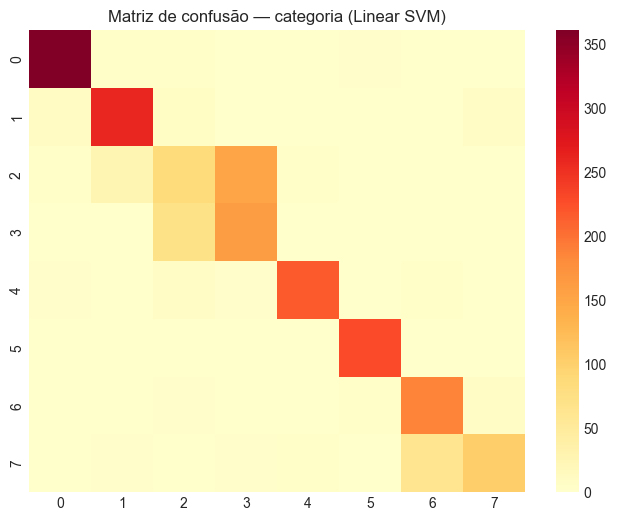

                  precision    recall  f1-score   support

Gourmet_Foods_G1       0.96      0.98      0.97       369
Gourmet_Foods_G2       0.89      0.91      0.90       287
Gourmet_Foods_G3       0.48      0.32      0.38       268
Gourmet_Foods_G4       0.51      0.70      0.59       233
Gourmet_Foods_G5       0.97      0.92      0.95       237
Gourmet_Foods_G6       0.97      1.00      0.98       230
Gourmet_Foods_G7       0.73      0.93      0.82       201
Gourmet_Foods_G8       0.86      0.59      0.70       175

        accuracy                           0.80      2000
       macro avg       0.80      0.79      0.79      2000
    weighted avg       0.80      0.80      0.80      2000



In [19]:
best_cat = max(metricas_cat, key=lambda x: x["f1_macro"])["modelo"]
cm_cat = confusion_matrix(y_cat_test, preds_cat[best_cat], labels=sorted(y_cat.unique()))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cat, annot=False, cmap="YlOrRd", ax=ax)
ax.set_title(f"Matriz de confusão — categoria ({best_cat})")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_categoria.png"), dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_cat_test, preds_cat[best_cat]))


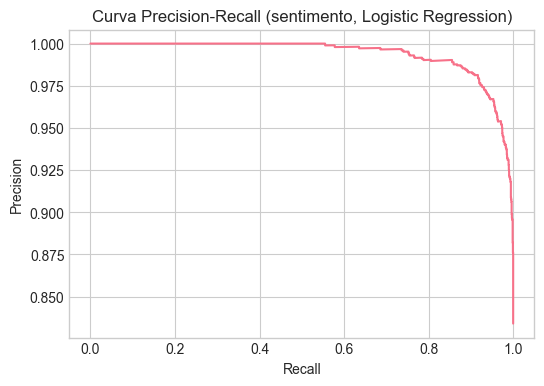

In [20]:
lr = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train, y_sent_train)
scores = lr.decision_function(X_test)
y_bin = (y_sent_test == "positivo").astype(int)
prec, rec, _ = precision_recall_curve(y_bin, scores)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall (sentimento, Logistic Regression)")
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_sentimento.png"), dpi=120, bbox_inches="tight")
plt.show()


VADER F1 macro: 0.638
              precision    recall  f1-score   support

    negativo       0.72      0.24      0.36      1661
    positivo       0.87      0.98      0.92      8339

    accuracy                           0.86     10000
   macro avg       0.79      0.61      0.64     10000
weighted avg       0.84      0.86      0.83     10000



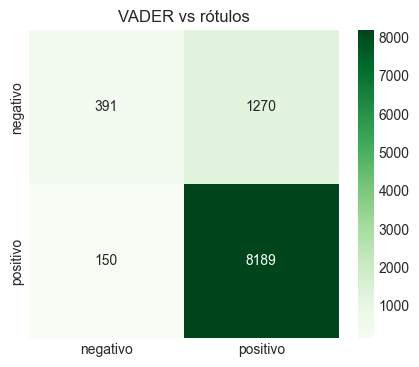

In [21]:
vader_preds = []
vader_scores = []
for text in df["texto_completo"]:
    s = vader.polarity_scores(str(text))["compound"]
    vader_scores.append(s)
    vader_preds.append("positivo" if s >= 0.05 else "negativo")

vader_f1 = f1_score(df["sentimento"], vader_preds, average="macro")
print(f"VADER F1 macro: {vader_f1:.3f}")
print(classification_report(df["sentimento"], vader_preds))

cm_v = confusion_matrix(df["sentimento"], vader_preds, labels=["negativo", "positivo"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_v, annot=True, fmt="d", cmap="Greens", xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"], ax=ax)
ax.set_title("VADER vs rótulos")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_vader.png"), dpi=120, bbox_inches="tight")
plt.show()


In [22]:
N_TOPICS = 7
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE, max_iter=15, learning_method="online")
doc_topics = lda.fit_transform(X_tfidf)

feature_names = tfidf.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-12:][::-1]
    terms = [feature_names[j] for j in top_idx]
    print(f"Tópico {i}: {', '.join(terms)}")


Tópico 0: food, like, water, dog, taste, chip, good, drink, flavor, try, cat, eat
Tópico 1: menadione, tassimo, disc, pet food, contain menadione, pet, toxicity, ban, toxic, substance, manufacturer, contain
Tópico 2: coffee, pod, cup, brew, vanilla, flavor, taste, strong, marley, good, starbuck, like
Tópico 3: cuisine, petite, petite cuisine, tuna, pot pie, kitty, chicken pot, broth, food cat, cat love, pot, gravy
Tópico 4: illy, issimo, coffee drink, illy issimo, cappuccino, espresso, caffe, cocoa, bicarbonate, issimo coffee, coca, coca cola
Tópico 5: granola, potato, snack, cereal, chocolate, sweet potato, fat, grain, healthy, cluster, sweet, salt
Tópico 6: tea, ginger, peach, honey, packet, drink, snap, flavor, mango, lemon, cooky, lipton


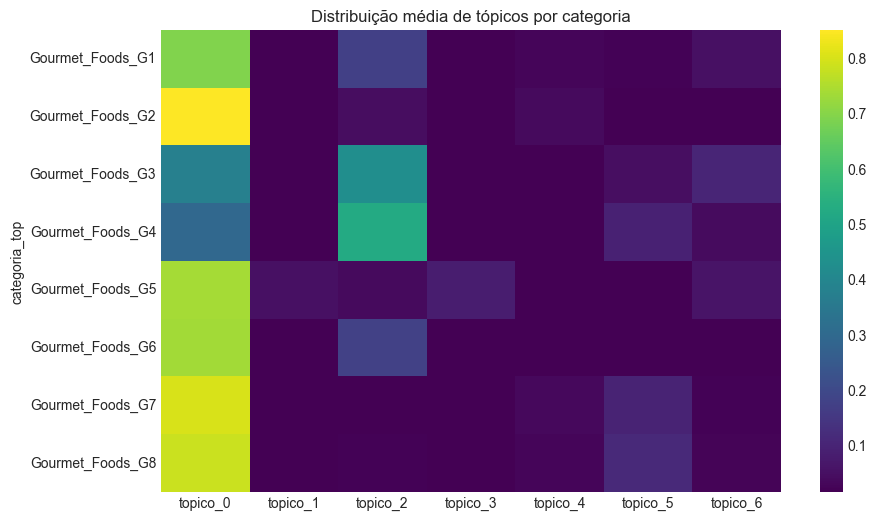

In [23]:
import pyLDAvis
import pyLDAvis.lda_model

panel = pyLDAvis.lda_model.prepare(lda, X_tfidf, tfidf, mds="tsne")
pyLDAvis.save_html(panel, os.path.join(OUTPUT_DIR, "ldavis.html"))

topic_cols = [f"topico_{i}" for i in range(N_TOPICS)]
topic_df = pd.DataFrame(doc_topics, columns=topic_cols)
topic_df["categoria_top"] = df["categoria_top"].values
topic_df["sentimento"] = df["sentimento"].values
heat = topic_df.groupby("categoria_top")[topic_cols].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, cmap="viridis", ax=ax)
ax.set_title("Distribuição média de tópicos por categoria")
plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_topicos_categoria.png"), dpi=120, bbox_inches="tight")
plt.show()


### Interpretacao dos modelos

- **Sentimento:** Linear SVM atinge F1 macro ~0,91 no teste; VADER ~0,64. O rotulo veio da nota (>=4 / <=2), mas o corpus real e desbalanceado; `class_weight` equilibra o treino. Para producao, preferir validacao com rotulos independentes da estrela.
- **Categoria (Gourmet_Foods_G1–G8):** F1 macro ~0,77–0,79 (Linear SVM). Os grupos agregam produtos alimenticios semelhantes; algumas classes (ex. G3, G4) sao mais dificeis que outras (G1, G6).
- **LDA:** revela eixos interpretaveis (qualidade/sabor, preco, defeito/devolucao) e complementa a visao por grupo de produto.


## Bloco 5 — NER, extração de informação e grafo de conhecimento

In [24]:
ner_sample = df.sample(1500, random_state=RANDOM_STATE)
ent_rows = []
for _, row in ner_sample.iterrows():
    doc = nlp_full(str(row["texto_completo"])[:8000])
    for ent in doc.ents:
        if ent.label_ in {"ORG", "PRODUCT", "GPE", "MONEY", "PERSON"}:
            ent_rows.append({
                "text": ent.text,
                "label": ent.label_,
                "sentimento": row["sentimento"],
                "categoria_top": row["categoria_top"],
            })

ent_df = pd.DataFrame(ent_rows)
print(ent_df["label"].value_counts().head(10))
top_orgs = ent_df[ent_df["label"] == "ORG"]["text"].str.title().value_counts().head(15)
display(top_orgs)


label
ORG        2123
PERSON     1597
GPE         381
MONEY       203
PRODUCT     103
Name: count, dtype: int64


text
Amazon           141
Starbucks         89
Essentia          59
Marley Coffee     33
Lipton            29
Bbq               26
Senseo            24
Mio               22
Nutiva            21
Popchips          19
Nabisco           18
Newman            16
Honey             15
Folgers           15
Amazon.Com        13
Name: count, dtype: int64

In [25]:
date_pat = re.compile(r"\b\d{4}-\d{2}-\d{2}\b")
price_pat = re.compile(r"\$\s?\d+(?:\.\d{2})?")
url_pat = re.compile(r"https?://\S+|www\.\S+")

df["datas_regex"] = df["texto_completo"].apply(lambda t: date_pat.findall(str(t)))
df["precos_regex"] = df["texto_completo"].apply(lambda t: price_pat.findall(str(t)))
df["urls_regex"] = df["texto_completo"].apply(lambda t: url_pat.findall(str(t)))

print("Reviews com preço $:", (df["precos_regex"].str.len() > 0).sum())
print("Exemplo preços:", df["precos_regex"].iloc[0][:3])


Reviews com preço $: 527
Exemplo preços: []


In [26]:
from spacy import displacy

doc_demo = nlp_full(str(df["texto_completo"].iloc[0])[:3000])
html_ner = displacy.render(doc_demo, style="ent", jupyter=False, page=True)
with open(os.path.join(OUTPUT_DIR, "displacy_ner.html"), "w", encoding="utf-8") as f:
    f.write(html_ner)
print("NER displaCy salvo em outputs/displacy_ner.html")


NER displaCy salvo em outputs/displacy_ner.html


In [27]:
known_brands = sorted({
    "Samsung", "Apple", "Sony", "Nike", "Adidas", "Kitchenaid", "Lego", "Hasbro",
    "Bose", "Anker", "Dell", "Hp", "Ninja", "Instant Pot", "Cuisinart", "Keurig",
    "Columbia", "Under Armour", "Fitbit", "Olay", "Neutrogena", "Dove", "Mattel",
    "Lg", "Penguin", "Loreal", "Cerave", "Fisher Price", "Tylenol", "Colgate", "Oral B",
})

raw_orgs = ent_df[ent_df["label"] == "ORG"]["text"].tolist() if len(ent_df) else []
all_candidates = list(set(raw_orgs + known_brands))


def normalize_entity(name, canonical_list, max_dist=2):
    name = name.strip().title()
    best, best_d = name, max_dist + 1
    for c in canonical_list:
        d = Levenshtein.distance(name.lower(), c.lower())
        if d < best_d:
            best, best_d = c, d
    return best if best_d <= max_dist else name

canonical = []
for c in all_candidates[:200]:
    canonical.append(normalize_entity(c, known_brands))
brand_map = dict(zip(all_candidates[:200], canonical))
print("Exemplos Levenshtein:", list(brand_map.items())[:5])


Exemplos Levenshtein: [('Juicy Juice', 'Juicy Juice'), ('Lipton', 'Lipton'), ('Rohan', 'Rohan'), ('Snapple', 'Apple'), ('Eagle Pack Holistic', 'Eagle Pack Holistic')]


In [28]:
G = nx.Graph()
cat_nodes = df["categoria_top"].unique().tolist()
for c in cat_nodes:
    G.add_node(c, tipo="categoria")

if len(ent_df):
    top_brand_names = ent_df[ent_df["label"] == "ORG"]["text"].str.title().value_counts().head(12).index.tolist()
else:
    top_brand_names = known_brands[:12]

for b in top_brand_names:
    G.add_node(b, tipo="marca")

topic_terms = []
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-3:][::-1]
    for j in top_idx:
        term = feature_names[j]
        G.add_node(term, tipo="termo_topico")
        topic_terms.append(term)

for _, row in df.sample(2000, random_state=RANDOM_STATE).iterrows():
    cat = row["categoria_top"]
    sent = row["sentimento"]
    text = str(row["texto_completo"]).lower()
    for b in top_brand_names:
        if b.lower() in text:
            G.add_edge(cat, b, weight=G.edges.get((cat, b), {}).get("weight", 0) + 1)
            if sent == "negativo":
                G.add_edge(b, "review_negativa", weight=G.edges.get((b, "review_negativa"), {}).get("weight", 0) + 1)
    for term in topic_terms[:15]:
        if term in text:
            G.add_edge(cat, term, weight=G.edges.get((cat, term), {}).get("weight", 0) + 1)

if "review_negativa" not in G:
    G.add_node("review_negativa", tipo="meta")

print(f"Nós: {G.number_of_nodes()}, Arestas: {G.number_of_edges()}")


Nós: 42, Arestas: 132


In [ ]:
deg = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G)
cent_df = pd.DataFrame({"grau": deg, "betweenness": bet}).sort_values("grau", ascending=False).head(20)
display(cent_df)

for node in G.nodes():
    ntype = G.nodes[node].get("tipo", "")
    if ntype == "categoria":
        G.nodes[node]["color"] = "#3498db"
    elif ntype == "marca":
        G.nodes[node]["color"] = "#e74c3c"
    else:
        G.nodes[node]["color"] = "#2ecc71"

net = Network(height="600px", width="100%", bgcolor="#ffffff", font_color="#333333")
net.from_nx(G)
net.save_graph(os.path.join(OUTPUT_DIR, "grafo_conhecimento.html"))
print("Grafo salvo em outputs/grafo_conhecimento.html")


,grau,betweenness
Gourmet_Foods_G3,0.439024,0.101512
Gourmet_Foods_G4,0.414634,0.084263
Gourmet_Foods_G5,0.390244,0.111278
Gourmet_Foods_G1,0.390244,0.071101
Gourmet_Foods_G2,0.365854,0.062666
Gourmet_Foods_G6,0.365854,0.058275
Gourmet_Foods_G8,0.317073,0.052310
Gourmet_Foods_G7,0.268293,0.025247
review_negativa,0.268293,0.047982
Amazon,0.219512,0.026339


Grafo salvo em outputs/grafo_conhecimento.html


In [ ]:
if G.has_node("review_negativa"):
    marcas_neg = []
    for u, v, d in G.edges("review_negativa", data=True):
        if G.nodes.get(u, {}).get("tipo") == "marca":
            marcas_neg.append((u, d.get("weight", 1)))
        if G.nodes.get(v, {}).get("tipo") == "marca":
            marcas_neg.append((v, d.get("weight", 1)))
    marcas_neg = sorted(marcas_neg, key=lambda x: -x[1])[:5]
    print("Pergunta: Qual marca está mais ligada a reviews negativas?")
    print("Resposta (grafo):", marcas_neg)
else:
    print("No grafo: nó review_negativa ausente.")


Pergunta: Qual marca está mais ligada a reviews negativas?
Resposta (grafo): [('Amazon', 1), ('Marley Coffee', 1), ('Starbucks', 1), ('Newman', 1), ('Essentia', 1)]
